In [1]:
!pip install -q ucimlrepo

from ucimlrepo import fetch_ucirepo
import pandas as pd

dataset = fetch_ucirepo(id=296)

X = dataset.data.features
y = dataset.data.targets

data = pd.concat([X, y], axis=1)

print("Dataset Shape:", data.shape)
data.head()

/usr/local/lib/python3.13/dist-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


Dataset Shape: (101766, 48)


,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,...,No,No,No,No,No,No,No,No,No,NO
1,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,...,No,No,No,No,No,No,No,No,Yes,NO
3,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [2]:
print("Columns:")
print(data.columns.tolist())

print("\nDataset Information:")
data.info()

Columns:
['race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 48 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------     

In [3]:
missing = data.isnull().sum()

print(missing[missing > 0])

race                  2273
weight               98569
payer_code           40256
medical_specialty    49949
diag_1                  21
diag_2                 358
diag_3                1423
max_glu_serum        96420
A1Cresult            84748
dtype: int64


In [4]:
missing_percent = (data.isnull().sum() / len(data)) * 100

print(missing_percent[missing_percent > 0].sort_values(ascending=False))

weight               96.858479
max_glu_serum        94.746772
A1Cresult            83.277322
medical_specialty    49.082208
payer_code           39.557416
race                  2.233555
diag_3                1.398306
diag_2                0.351787
diag_1                0.020636
dtype: float64


In [9]:
data = data.drop(columns=[
    'weight',
    'max_glu_serum',
    'A1Cresult',
    'medical_specialty',
    'payer_code'
])

print("New Dataset Shape:", data.shape)

KeyError: "['weight', 'max_glu_serum', 'A1Cresult', 'medical_specialty', 'payer_code'] not found in axis"

In [10]:
print(data.columns.tolist())

['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


In [11]:
print("Dataset Shape:", data.shape)
print("\nRemaining Missing Values:")
print(data.isnull().sum()[data.isnull().sum() > 0])

Dataset Shape: (101766, 43)

Remaining Missing Values:
race      2273
diag_1      21
diag_2     358
diag_3    1423
dtype: int64


In [12]:
# Fill missing categorical values with "Unknown"

data['race'] = data['race'].fillna('Unknown')
data['diag_1'] = data['diag_1'].fillna('Unknown')
data['diag_2'] = data['diag_2'].fillna('Unknown')
data['diag_3'] = data['diag_3'].fillna('Unknown')

print("Remaining Missing Values:")
print(data.isnull().sum()[data.isnull().sum() > 0])

Remaining Missing Values:
Series([], dtype: int64)


In [13]:
data['readmitted'] = data['readmitted'].map({
    '<30': 1,
    '>30': 0,
    'NO': 0
})

print(data['readmitted'].value_counts())

readmitted
0    90409
1    11357
Name: count, dtype: int64


In [14]:
print("Target Distribution:")
print(data['readmitted'].value_counts())

print("\nTarget Percentage:")
print(data['readmitted'].value_counts(normalize=True) * 100)

Target Distribution:
readmitted
0    90409
1    11357
Name: count, dtype: int64

Target Percentage:
readmitted
0    88.840084
1    11.159916
Name: proportion, dtype: float64


In [15]:
X = data.drop(columns=['readmitted'])
y = data['readmitted']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (101766, 42)
Target Shape: (101766,)


In [16]:
categorical_columns = X.select_dtypes(include=['object']).columns

print("Categorical Columns:")
print(categorical_columns.tolist())

print("\nTotal Categorical Columns:", len(categorical_columns))

Categorical Columns:
['race', 'gender', 'age', 'diag_1', 'diag_2', 'diag_3', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']

Total Categorical Columns: 31


In [17]:
X_encoded = pd.get_dummies(X, columns=categorical_columns, drop_first=True)

print("Original Features:", X.shape)
print("Encoded Features:", X_encoded.shape)

Original Features: (101766, 42)
Encoded Features: (101766, 2330)


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (81412, 2330)
X_test: (20354, 2330)
y_train: (81412,)
y_test: (20354,)


In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

X_train_scaled: (81412, 2330)
X_test_scaled: (20354, 2330)


In [20]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    penalty='l2',
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [21]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Predictions generated successfully!")
print("First 10 Predictions:", y_pred[:10])
print("First 10 Probabilities:", y_prob[:10])

Predictions generated successfully!
First 10 Predictions: [0 0 0 0 0 0 0 0 0 0]
First 10 Probabilities: [0.13466598 0.05925086 0.14320971 0.24077797 0.11087024 0.03114626
 0.05415452 0.0662004  0.25275791 0.19400253]


In [22]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.6350308510639076


In [24]:
from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18083
           1       0.44      0.03      0.05      2271

    accuracy                           0.89     20354
   macro avg       0.66      0.51      0.49     20354
weighted avg       0.84      0.89      0.84     20354


Confusion Matrix:
[[18008    75]
 [ 2213    58]]


In [25]:
from sklearn.metrics import confusion_matrix, classification_report

threshold = 0.30

y_pred_threshold = (y_prob >= threshold).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_threshold))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_threshold))

Confusion Matrix:
[[17681   402]
 [ 2074   197]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.98      0.93     18083
           1       0.33      0.09      0.14      2271

    accuracy                           0.88     20354
   macro avg       0.61      0.53      0.54     20354
weighted avg       0.83      0.88      0.85     20354



In [26]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.50, 0.40, 0.30, 0.20, 0.10]

for threshold in thresholds:
    y_pred_temp = (y_prob >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_temp)
    recall = recall_score(y_test, y_pred_temp)
    f1 = f1_score(y_test, y_pred_temp)

    print("Threshold:", threshold)
    print("Precision:", round(precision, 3))
    print("Recall:", round(recall, 3))
    print("F1-Score:", round(f1, 3))
    print("----------------------")

Threshold: 0.5
Precision: 0.436
Recall: 0.026
F1-Score: 0.048
----------------------
Threshold: 0.4
Precision: 0.352
Recall: 0.041
F1-Score: 0.073
----------------------
Threshold: 0.3
Precision: 0.329
Recall: 0.087
F1-Score: 0.137
----------------------
Threshold: 0.2
Precision: 0.241
Recall: 0.2
F1-Score: 0.218
----------------------
Threshold: 0.1
Precision: 0.154
Recall: 0.631
F1-Score: 0.247
----------------------


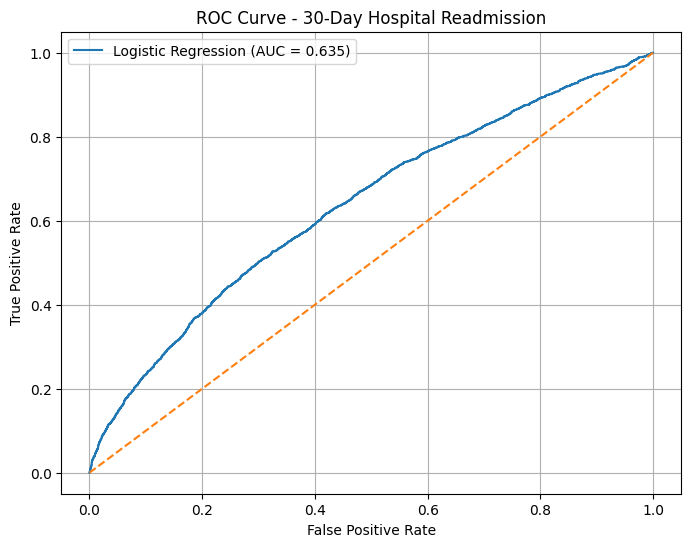

In [27]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - 30-Day Hospital Readmission")
plt.legend()
plt.grid()

plt.show()

In [28]:
print("===== FINAL MODEL RESULTS =====")

print("Model: Logistic Regression")
print("Regularization: L2")
print("ROC-AUC:", round(roc_auc, 3))

print("\nSelected Threshold: 0.10")
print("Precision:", 0.154)
print("Recall:", 0.631)
print("F1-Score:", 0.247)

===== FINAL MODEL RESULTS =====
Model: Logistic Regression
Regularization: L2
ROC-AUC: 0.635

Selected Threshold: 0.10
Precision: 0.154
Recall: 0.631
F1-Score: 0.247


In [29]:
print("===== CLINICAL COST ANALYSIS =====")

print("False Negative (FN): Actual readmission patient predicted as No Readmission.")
print("Clinical impact: A high-risk patient may be missed for timely follow-up or intervention.")

print("\nFalse Positive (FP): Actual non-readmission patient predicted as Readmission.")
print("Clinical impact: May lead to unnecessary follow-up, monitoring, or resource use.")

print("\nFor this problem, False Negatives are generally more concerning.")
print("Therefore, a lower classification threshold can improve recall.")

===== CLINICAL COST ANALYSIS =====
False Negative (FN): Actual readmission patient predicted as No Readmission.
Clinical impact: A high-risk patient may be missed for timely follow-up or intervention.

False Positive (FP): Actual non-readmission patient predicted as Readmission.
Clinical impact: May lead to unnecessary follow-up, monitoring, or resource use.

For this problem, False Negatives are generally more concerning.
Therefore, a lower classification threshold can improve recall.
